In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

random.seed(42)
np.random.seed(42)

os.chdir('/hpc/scratch/977879/roman_urdu_sentiment')

print("All libraries imported successfully")

All libraries imported successfully


In [4]:
df = pd.read_csv('Dataset 11000 Reviews.csv')

print(df.shape)
print(df.columns.tolist())
df.head()

(11000, 2)
['Label', 'text']


,Label,text
0,neg,ab achanak khawaja saad rafique ko khiyaal aa...
1,neg,"adha drama to censor hi hojaye gaa , khaas to..."
2,neg,bekaar fuzool end !!!!! moti budhi laila jeet...
3,neg,choor kasuri choor jhootay ka moo kaala
4,neg,gali gali mein shor hai gaaanjaaaa shair chor...


In [5]:
print(df.isnull().sum())
print(df['Label'].value_counts())

Label    0
text     0
dtype: int64
Label
pos    5699
neg    5300
          1
Name: count, dtype: int64


In [6]:
df = df[df['Label'].isin(['pos', 'neg'])]
df = df.reset_index(drop=True)

print(df.shape)
print(df['Label'].value_counts())

(10999, 2)
Label
pos    5699
neg    5300
Name: count, dtype: int64


In [7]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip().lower()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

print(df['text'].iloc[0])
print()
print(df['cleaned_text'].iloc[0])

 ab achanak khawaja saad rafique ko khiyaal aagaya woh bhe peshawar mai is line pai 10 saal sai koi train nahe guzri

ab achanak khawaja saad rafique ko khiyaal aagaya woh bhe peshawar mai is line pai 10 saal sai koi train nahe guzri


In [8]:
df['label_encoded'] = df['Label'].map({'pos': 1, 'neg': 0})

print(df[['Label', 'label_encoded']].value_counts())

df[['cleaned_text', 'label_encoded']].to_csv('rusad_cleaned.csv', index=False)

print(df.shape)

Label  label_encoded
pos    1                5699
neg    0                5300
Name: count, dtype: int64
(10999, 4)


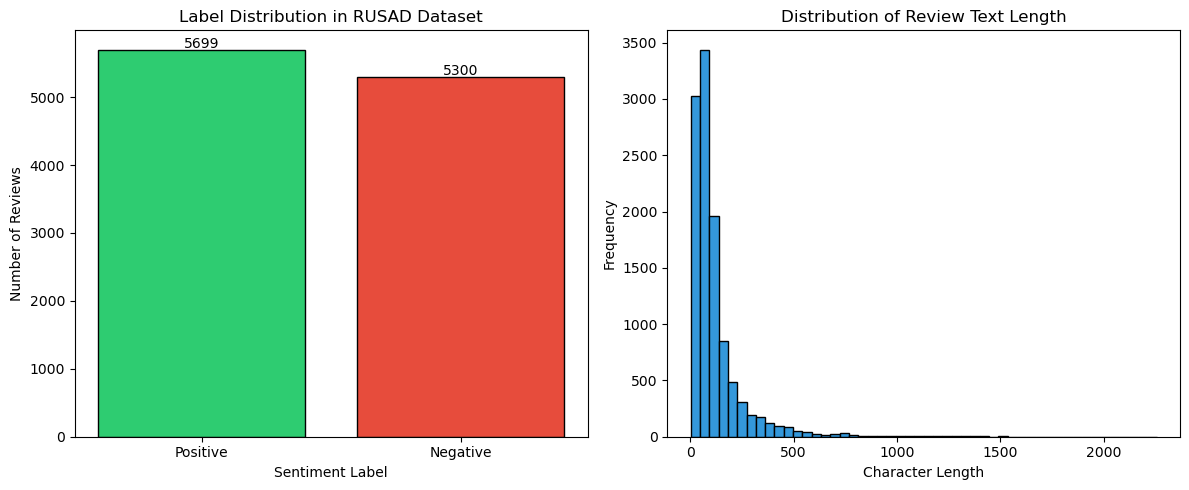

In [9]:
df['text_length'] = df['cleaned_text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Positive', 'Negative'], [5699, 5300], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Label Distribution in RUSAD Dataset')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Number of Reviews')
axes[0].text(0, 5699 + 30, '5699', ha='center')
axes[0].text(1, 5300 + 30, '5300', ha='center')

axes[1].hist(df['text_length'], bins=50, color='#3498db', edgecolor='black')
axes[1].set_title('Distribution of Review Text Length')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('EDA_figures.png', dpi=150, bbox_inches='tight')
plt.show()